In [1]:
import os
os.chdir("..")
from qwen_vl import *
import torch
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from plyfile import PlyData
from autoencoder.model_qwen import QwenAutoencoder

In [2]:
# data_path = Path('output/hypernerf/chickchicken_qwen/chickchicken_qwen_0_base/graph')
# feature_render_path = Path('output/hypernerf/chickchicken_qwen/chickchicken_qwen_0_qwenF3/video_lang/ours_10000/renders_npy/00047.npy')
# base_feature_path = Path('output/hypernerf/chickchicken_qwen/chickchicken_qwen_0_qwenF3/video_lang/ours_10000/gt_npy/00047.npy')
data_path = Path('output/cholecseg8k/video01/video01_00080/rgb/graph')
feature_render_path = Path('output/cholecseg8k/video01/video01_00080/qwen_patch/video_lang/ours_10000/renders_npy/00047.npy')
base_feature_path = Path('output/cholecseg8k/video01/video01_00080/qwen_patch/video_lang/ours_10000/renders_npy/00047.npy')

In [3]:
lf = np.load(data_path / "qwen_latents.npy")
opacities = np.load(data_path / "opacities.npy").flatten()
pos = np.load(data_path / "positions.npy")
clusters = np.load(data_path / "clusters.npy")

In [4]:
print(f"lf:        {lf.shape}")
print(f"opacities: {opacities.shape}")
print(f"pos:       {pos.shape}")
print(f"clusters:  {clusters.shape}")

lf:        (62521, 3)
opacities: (62521,)
pos:       (62521, 3)
clusters:  (62521,)


In [5]:
feature_render = np.load(feature_render_path)
feature_render_norm = np.linalg.norm(feature_render, axis=-1)
base_features = np.load(base_feature_path)

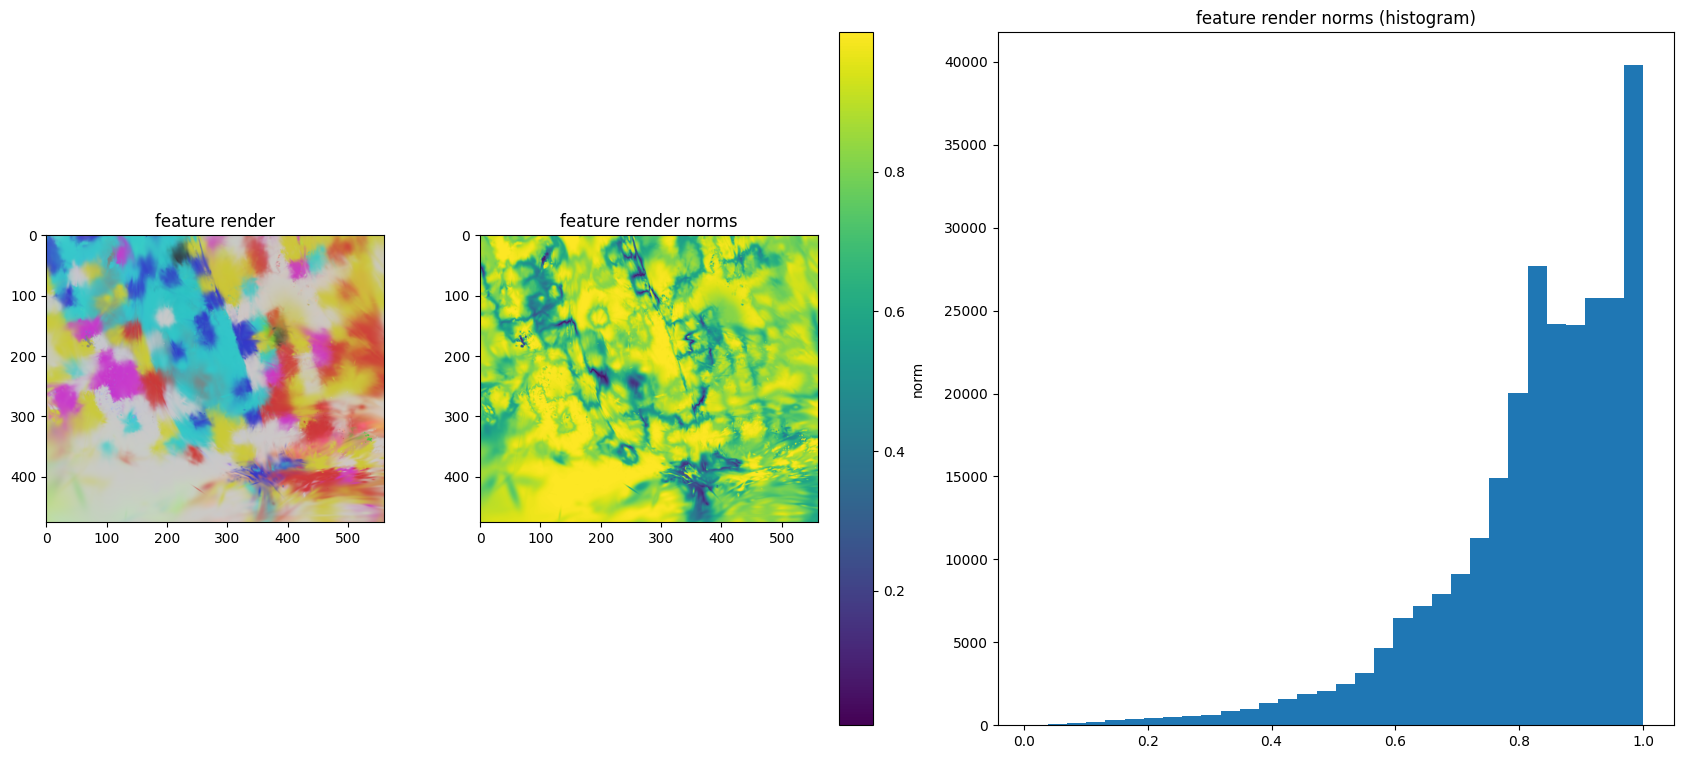

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(21, 9), gridspec_kw={'width_ratios': [1, 1.25, 2]})
axs[0].imshow(feature_render / 2. + 0.5)
axs[0].set_title("feature render")
im = axs[1].imshow(feature_render_norm)
fig.colorbar(im, ax=axs[1], label="norm")
axs[1].set_title("feature render norms")
axs[2].hist(feature_render_norm.flatten(), bins=32)
axs[2].set_title("feature render norms (histogram)")
plt.show()

## Opacity stuff

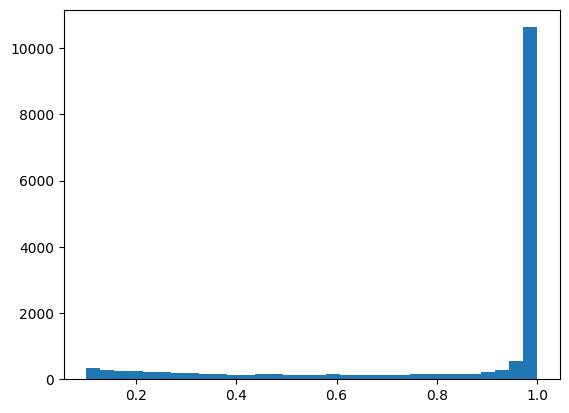

In [7]:
plt.hist(opacities, bins=32)
plt.show()

In [ ]:
fig, axs = plt.subplots(1, 2)
axs[0].hist(np.linalg.norm(lf, axis=-1))
axs[0].set_title("Latent feature norms")
plt.plot()

In [49]:
opacities[np.argpartition(opacities, -10)[-10:]]

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], dtype=float32)

In [6]:
ply_qwen = PlyData.read("output/hypernerf/chickchicken_qwen/chickchicken_qwen_0_qwenF3/point_cloud/fine-lang_iteration_10000/point_cloud.ply")['vertex']
ply_rgb = PlyData.read("output/hypernerf/chickchicken_qwen/chickchicken_qwen_0_base/point_cloud/fine-base_iteration_10000/point_cloud.ply")['vertex']

In [7]:
np.allclose(
    np.asanyarray(ply_rgb['opacity']),
    np.asanyarray(ply_qwen['opacity']),
)

True

In [9]:
ply_opacity = ply_rgb['opacity']
ply_opacity_sigmoid = torch.sigmoid(torch.as_tensor(ply_opacity)).numpy()

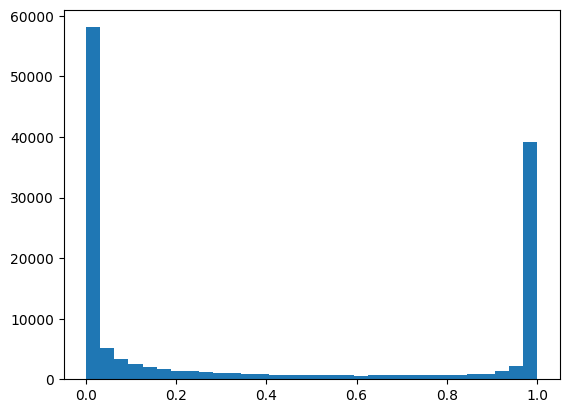

In [11]:
plt.hist(ply_opacity_sigmoid, bins=32)
plt.show()

[]

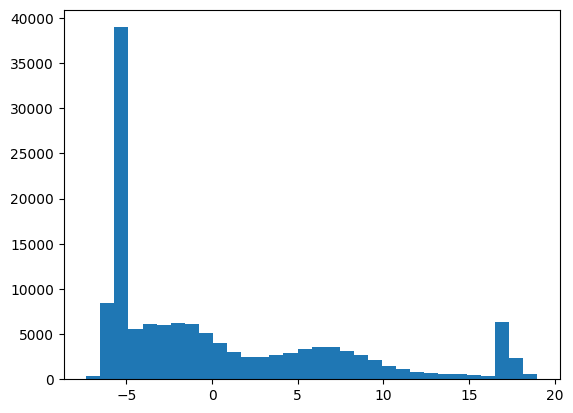

In [8]:
plt.hist(np.asanyarray(ply_rgb['opacity']), bins=32)
plt.plot()

## Scaling experiments

In [8]:
lf_scaled_by_op = lf * opacities[:, None]
lf_normed = lf / np.linalg.norm(lf, axis=-1, keepdims=True)

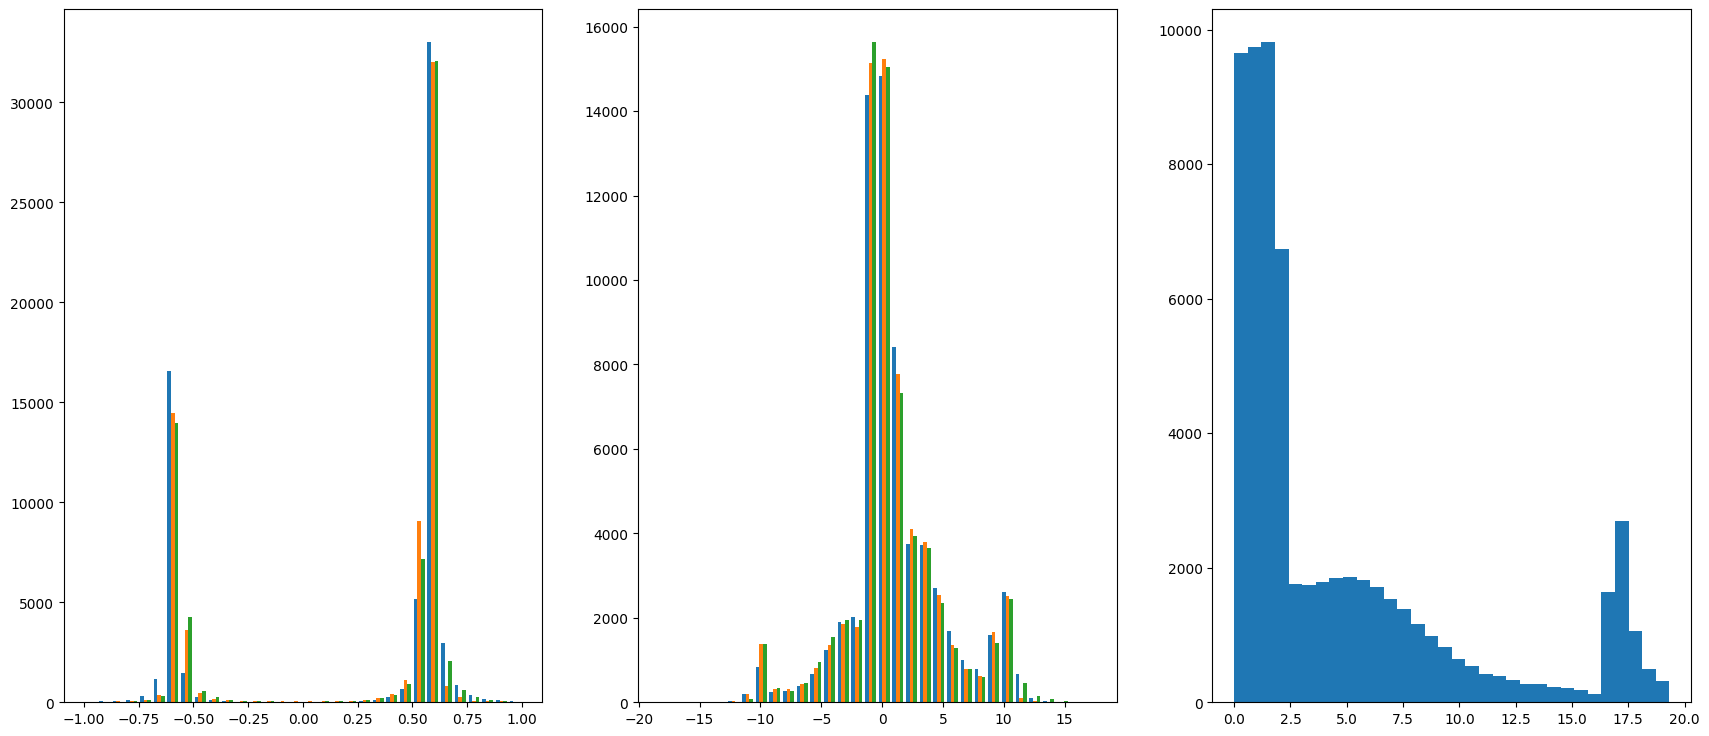

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(21, 9))
axs[0].hist(lf, bins=32)
axs[1].hist(lf_scaled_by_op, bins=32)
axs[2].hist(np.linalg.norm(lf_scaled_by_op, axis=-1), bins=32)
plt.show()

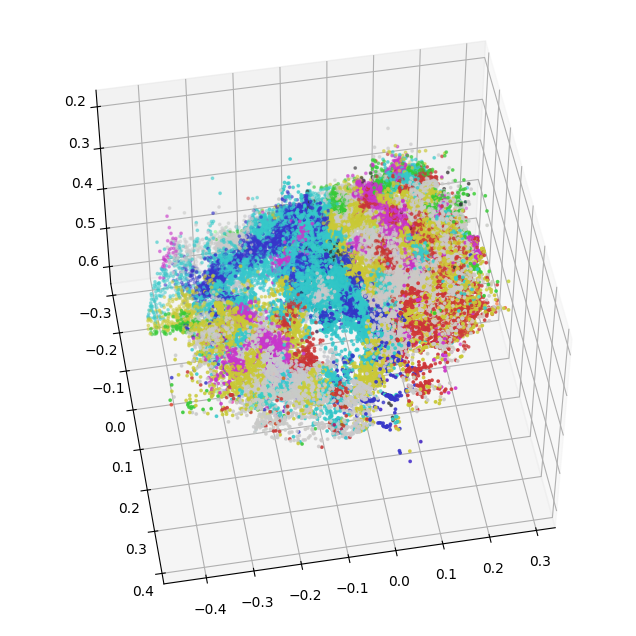

In [10]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')
ax.scatter(*pos.T, s=3, c=np.clip((lf_normed)/2+0.5, a_min=0.0, a_max=1.0))
ax.view_init(elev=-130, azim=-80)
plt.show()

#TODO: looks like we're filtering based on opacity too aggressively

In [4]:
gt_lf = np.load('data/cholecseg8k/preprocessed_ssg/video01/video01_00080/qwen_patch_features_dim3/000047_f.npy')
img = Image.open('data/cholecseg8k/preprocessed_ssg/video01/video01_00080/images/frame_000047.jpg')

In [5]:
ask_qwen_about_image(img, "Describe the scene.", model, processor)

'The image shows the intraoperative view of a patient undergoing a laparoscopic cholecystectomy. The gallbladder is visible in the center, with its neck and cystic duct being dissected or prepared for ligation. The liver is on the right side, and the surrounding structures, including the duodenum and other abdominal organs, are also visible. This is a critical step in the procedure where the gallbladder is being isolated from the liver and other structures.'

In [ ]:
ae.encode(qwen_encode_image(img, model, processor).to(torch.float32)).detach().cpu().numpy()

tensor([[-0.3049, -0.1443, -0.9414],
        [-0.6810,  0.1197, -0.7225],
        [-0.9023,  0.3829,  0.1980],
        ...,
        [-0.3644,  0.6843,  0.6316],
        [ 0.8071, -0.5655,  0.1697],
        [-0.6263,  0.7548,  0.1947]], device='cuda:0', grad_fn=<DivBackward0>)

In [6]:
ask_qwen_about_image_features(qwen_encode_image(img, model, processor).to(torch.float32), "Describe the scene.", model, processor)

'The image shows the intraoperative view of a patient undergoing a laparoscopic cholecystectomy. The gallbladder is visible in the center, with its neck and cystic duct being dissected or prepared for ligation. The liver is on the right side, and the surrounding structures, including the duodenum and other abdominal organs, are also visible. The area appears clean and well-lit, typical of a surgical field during a minimally invasive procedure.'

In [7]:
gt_lf

array([[-0.29839605, -0.14431927, -0.943468  ],
       [-0.69028586,  0.11915062, -0.7136586 ],
       [-0.89673287,  0.38591003,  0.21666503],
       ...,
       [ 0.8382146 , -0.38830295,  0.38290614],
       [ 0.8009371 , -0.57130724,  0.17918634],
       [-0.6235882 ,  0.7469969 ,  0.23050676]],
      shape=(340, 3), dtype=float32)

In [7]:
ask_qwen_about_image_features(ae.decode(torch.tensor(gt_lf, device='cuda')), "Describe the scene.", model, processor)

'The image shows a close-up view of the abdominal cavity during a surgical procedure. A portion of the liver is visible on the right side, with its characteristic red color and texture. On the left side, there appears to be a section of the gallbladder that has been mobilized or partially removed. The surrounding tissue includes the peritoneum and other abdominal structures. This scene likely depicts part of a laparoscopic cholecystectomy, where the gallbladder is being dissected from the liver bed.'

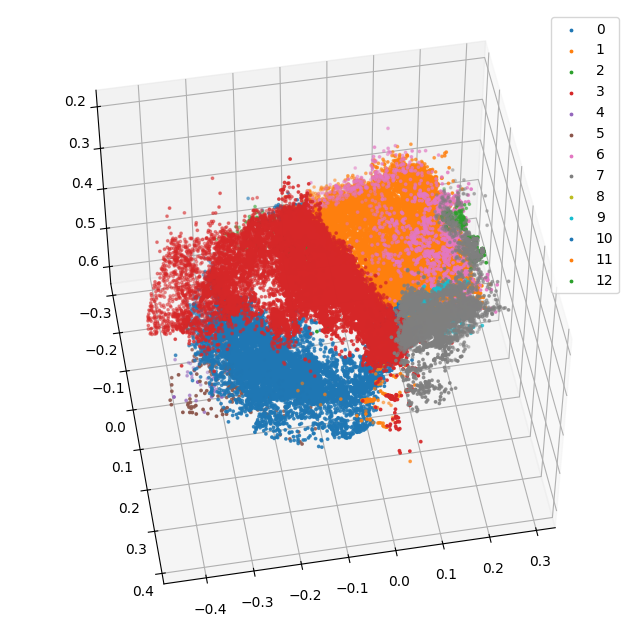

In [12]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')
for cluster_id in np.unique(clusters):
    ax.scatter(*pos[clusters == cluster_id].T, s=3, label=str(cluster_id))
ax.view_init(elev=-130, azim=-80) #type:ignore
ax.legend()
plt.show()

In [11]:
egg_cluster_id = 15
upper_hand_cluster_id = 13

In [13]:
gb_cluster_id = 3

In [14]:
model, processor = get_patched_qwen(use_bnb_4bit=False)

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


In [15]:
ae_ckpt_path = Path('data/cholecseg8k/preprocessed_ssg/video01/video01_00080/autoencoder/best_ckpt.pth')
ae = QwenAutoencoder(latent_dim=3).to("cuda")
ae.load_state_dict(torch.load(ae_ckpt_path))
ae.eval()
pass

In [16]:
qf = torch.tensor(lf, device="cuda")
qf_normed = torch.tensor(lf_normed, device="cuda")
qf_scaled_by_op = torch.tensor(lf_scaled_by_op, device="cuda")

In [17]:
c_map = lambda c: c/2.0+0.5

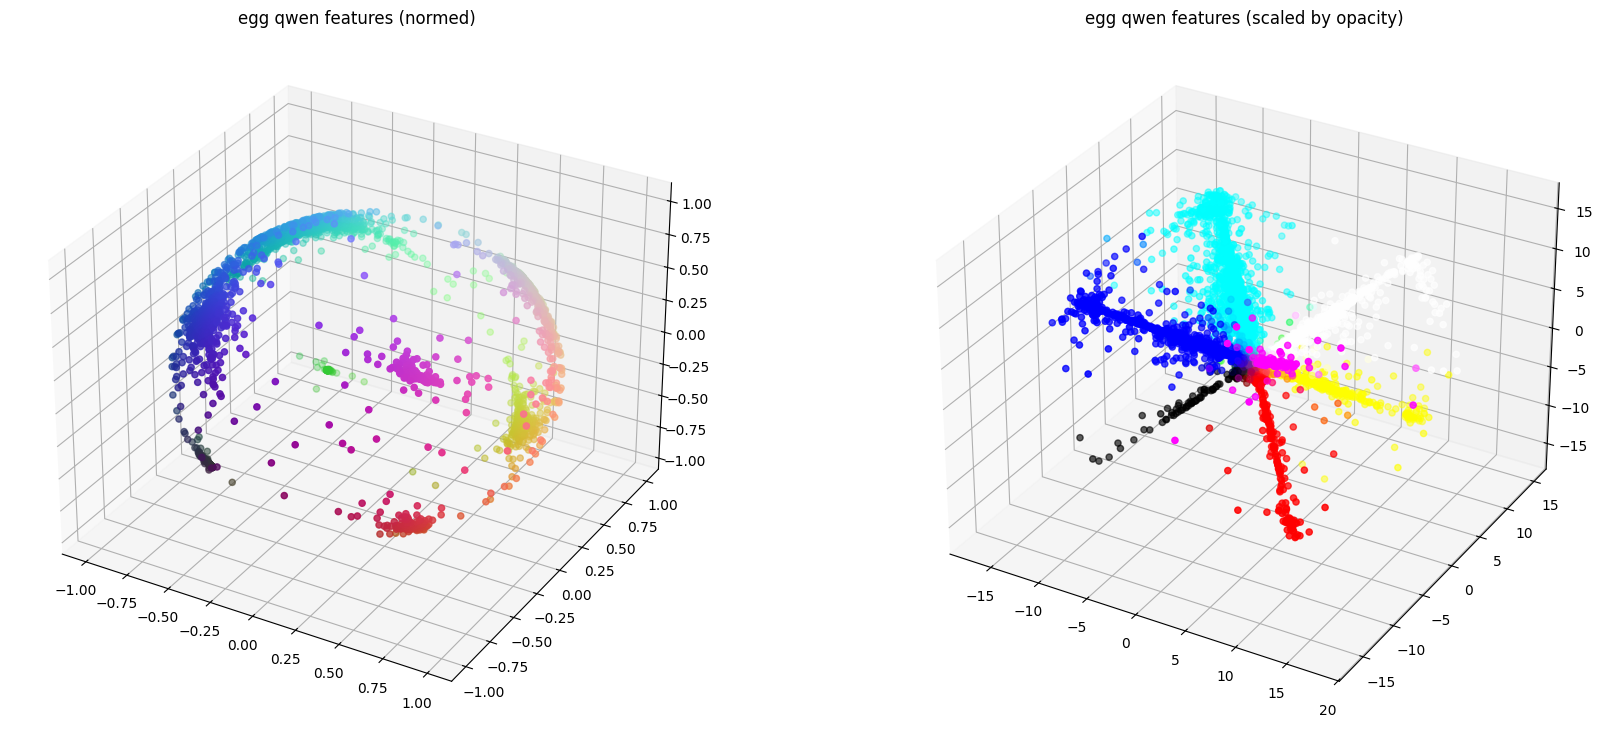

In [19]:
fig, axs = plt.subplots(1, 2, subplot_kw={'projection':'3d'}, figsize=(21, 9))
axs[0].scatter(*lf_normed[clusters == gb_cluster_id].T, c=c_map(lf_normed[clusters == gb_cluster_id]))
axs[0].set_title("egg qwen features (normed)")
axs[1].scatter(*lf_scaled_by_op[clusters == gb_cluster_id].T, c=np.clip(c_map(lf_scaled_by_op[clusters == gb_cluster_id]), a_min=0., a_max=1.))
axs[1].set_title("egg qwen features (scaled by opacity)")
plt.show()

In [21]:
from sklearn.cluster import HDBSCAN, KMeans

In [22]:
hdb = HDBSCAN(min_cluster_size=20)
gb_feature_clusters = hdb.fit_predict(lf_normed[clusters == gb_cluster_id])

In [20]:
hdb = HDBSCAN(min_cluster_size=20)
upper_hand_feature_clusters = hdb.fit_predict(lf_normed[clusters == upper_hand_cluster_id])

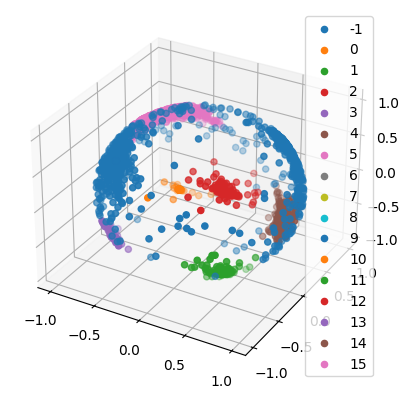

In [23]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
for subcluster_id in np.unique(gb_feature_clusters):
    ax.scatter(*lf_normed[clusters == gb_cluster_id][gb_feature_clusters == subcluster_id].T, label=str(subcluster_id))
ax.legend()
plt.show()

In [25]:
means = []
for subcluster_id in np.unique(gb_feature_clusters)[1:]:
    feature_mean = lf_normed[clusters == gb_cluster_id][gb_feature_clusters == subcluster_id].mean(axis=0)
    means.append(feature_mean / np.linalg.norm(feature_mean))
means = np.stack(means)

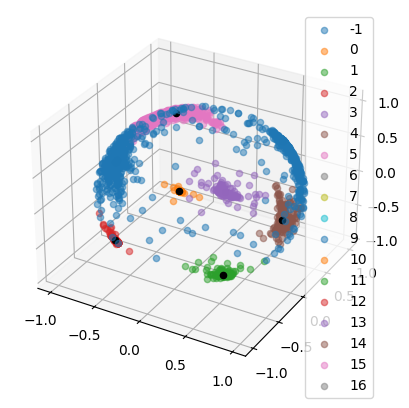

In [29]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
for subcluster_id in np.unique(gb_feature_clusters):
    ax.scatter(*lf_normed[clusters == gb_cluster_id][gb_feature_clusters == subcluster_id].T, label=str(subcluster_id), depthshade=False, alpha=0.5)
ax.scatter(*means.T, c='black', depthshade=False) #type:ignore
ax.legend()
plt.show()

In [30]:
_, counts = np.unique(gb_feature_clusters, return_counts=True)
print(f"Reduced feature count from {counts.sum()} -> {counts[0] + counts.size-1}")

Reduced feature count from 17681 -> 5436


In [19]:
egg_qf = torch.tensor(means, device='cuda')

In [24]:
hand_qf = torch.tensor(means, device='cuda')

In [24]:
gb_qf = torch.tensor(means, device='cuda')

NameError: name 'means' is not defined

In [34]:
ask_qwen_about_image_features(ae.decode(gb_qf), "Describe this image.", model, processor)

"This image appears to be a close-up view of a surgical site, possibly showing a tissue or organ with visible blood vessels and a slightly reddish hue. It could be part of an abdominal or pelvic procedure, given the context of the tissue's appearance and the presence of blood vessels. However, without more context, it is difficult to provide a precise description or diagnosis."

In [20]:
gb_qf_full = torch.tensor(lf_normed[clusters == gb_cluster_id], device='cuda')

In [24]:
# ask_qwen_about_image_features(ae.decode(gb_qf_full[torch.randint(0, gb_qf_full.shape[0], (200,))]), "Describe this image.", model, processor)
ask_qwen_about_image_features(ae.decode(gb_qf_full[torch.randint(0, gb_qf_full.shape[0], (1000,))]), "Describe this image.", model, processor)

'This image appears to be a close-up view of the abdominal cavity during a surgical procedure, likely a cholecystectomy (gallbladder removal). The visible structures include parts of the liver and possibly the gallbladder area. The tissue is being manipulated, which is typical in such surgeries. The image shows the internal anatomy with some blood vessels visible, indicating that the surgery is actively taking place.'

In [27]:
torch.randint(0, 10, (10,))

tensor([8, 0, 1, 6, 9, 0, 4, 3, 7, 3])

In [25]:
hand_qf_bg = torch.tensor(lf_normed[clusters == upper_hand_cluster_id][upper_hand_feature_clusters == -1], device='cuda')
# egg_qf_bg = egg_qf_bg[torch.randint(0, egg_qf_bg.shape[0], (10,))]
centers_w_bg = torch.cat((hand_qf, hand_qf_bg), dim=0)

In [30]:
ask_qwen_about_image_features(ae.decode(centers_w_bg), "What are the central objects visible in the image?", model, processor, system_prompt="You are a helpful assistant.")

'The central object in the image is a red egg-shaped container with a lid that is partially open, revealing an egg inside. The container appears to be designed for holding and possibly cooking or boiling eggs.'

In [36]:
bg_features = lf_normed[clusters == gb_cluster_id][gb_feature_clusters == -1]
kmeans = KMeans(n_clusters=32, random_state=42).fit(bg_features)
means = kmeans.cluster_centers_ / np.linalg.norm(kmeans.cluster_centers_, axis=-1, keepdims=True)

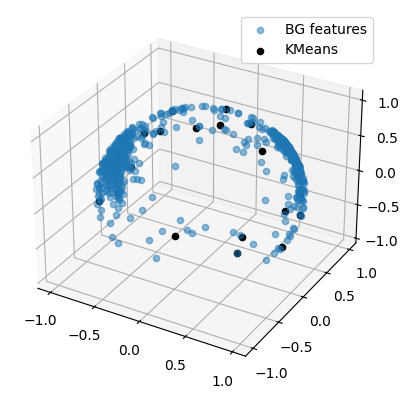

In [37]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(*bg_features.T, label="BG features", depthshade=False, alpha=0.5)
ax.scatter(*means.T, c='black', depthshade=False, label="KMeans")
ax.legend()
plt.show()

In [39]:
gb_qf_bg_kmeans = torch.tensor(means, device='cuda')
# egg_qf_bg = egg_qf_bg[torch.randint(0, egg_qf_bg.shape[0], (10,))]
centers_w_bg_kmeans = torch.cat((gb_qf, gb_qf_bg_kmeans), dim=0)

In [41]:
ask_qwen_about_image_features(ae.decode(centers_w_bg_kmeans), "Which organ is visible here?", model, processor)

'The image shows the stomach.'